<a href="https://colab.research.google.com/github/GaboGolCs/PainPredict-Neuro/blob/notebooks%2Fmodelos%2Fg3-Hito-4-Actividad-1-xgboost_refinado_eeg.ipynb/notebooks/modelos/xgboost_refinado_eeg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Instalación de dependencias



In [ ]:
# Instalación de dependencias en el entorno de Colab.
# 'imbalanced-learn' aporta SMOTETomek y el Pipeline que aísla el balanceo del set de test.
# 'mlflow' gestiona el registro de experimentos contra el servidor remoto de DagsHub.
!pip install -q xgboost imbalanced-learn scikit-learn mlflow seaborn matplotlib pandas numpy

## Importaciones y configuración global

Se importan las herramientas de modelado, validación y registro. Se fija una semilla global
para que la generación de muestras sintéticas, los splits y el entrenamiento sean
reproducibles entre ejecuciones.

In [ ]:
import os
import warnings

import numpy as np
import pandas as pd
import xgboost as xgb
import mlflow
import mlflow.sklearn
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, GridSearchCV, cross_val_predict
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score,
    precision_score, recall_score, confusion_matrix
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek

# Semilla única que se propaga a todos los componentes estocásticos del flujo.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Se silencian advertencias no críticas para mantener legible la salida del notebook.
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
print("Entorno listo. Versiones principales:")
print(f"  xgboost      : {xgb.__version__}")
print(f"  mlflow       : {mlflow.__version__}")

Entorno listo. Versiones principales:
  xgboost      : 3.2.0
  mlflow       : 3.13.0


## Conexión con MLflow (DagsHub)

El seguimiento de experimentos apunta al repositorio remoto de DagsHub. Las credenciales se
leen como variables de entorno.

> **Importante:** completa los tres campos marcados con tu información de DagsHub. El **token
> es personal y privado**: elimínalo del código antes de subir el notebook a GitHub
> (déjalo como cadena vacía o un *placeholder*).

In [ ]:
# --- CONFIGURACIÓN DE MLFLOW / DAGSHUB ---
# Completar con las credenciales propias. NO subir el token real al repositorio GitHub.
os.environ["MLFLOW_TRACKING_URI"]      = "https://dagshub.com/GaboGolCs/PainPredict-Neuro.mlflow"   # <-- URI .mlflow del repositorio DagsHub
os.environ["MLFLOW_TRACKING_USERNAME"] = "TU_USUARIO" # <-- usuario de DagsHub
os.environ["MLFLOW_TRACKING_PASSWORD"] = "TU_TOKEN_AQUI" # <-- token de acceso de DagsHub

# Nombre del experimento bajo el cual se agruparán todas las corridas de este modelo.
mlflow.set_experiment("XGBoost_EEG_Refinado_G5")

# Se desactiva el autolog para registrar manualmente el Pipeline completo de forma controlada,
# evitando que se dupliquen métricas o se registren artefactos intermedios no deseados.
mlflow.autolog(disable=True)

print("MLflow configurado. Tracking URI:", os.environ["MLFLOW_TRACKING_URI"] or "(vacío - completar)")

MLflow configurado. Tracking URI: https://dagshub.com/GaboGolCs/PainPredict-Neuro.mlflow


## Carga del dataset y definición del target

Se carga el CSV de features EEG ya normalizadas. La variable objetivo `nrs_score` toma cuatro
valores (32–35) que se reasignan a clases ordinales **0, 1, 2 y 3** correspondientes a niveles
crecientes de dolor.

La columna `subject_id` identifica al paciente y se usa más adelante como variable de
agrupación para que la validación cruzada respete el aislamiento de sujetos.

In [ ]:
from google.colab import drive; drive.mount('/content/drive')
RUTA_CSV = '/content/drive/Shareddrives/DATA_GPI/Datasets Normalizados/dataset_features_eeg_normalizado.csv'

df = pd.read_csv(RUTA_CSV)

# Mapeo del puntaje clínico NRS a etiquetas de clase ordinales (0 = menor dolor, 3 = mayor dolor).
MAPEO_TARGET = {32: 0, 33: 1, 34: 2, 35: 3}
df['target'] = df['nrs_score'].map(MAPEO_TARGET)

print("Dimensiones del dataset:", df.shape)
print("Sujetos únicos:", df['subject_id'].nunique())
print("\nDistribución de clases (target):")
print(df['target'].value_counts().sort_index())
print("\nProporción relativa por clase:")
print((df['target'].value_counts(normalize=True).sort_index() * 100).round(1).astype(str) + ' %')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dimensiones del dataset: (5729, 12)
Sujetos únicos: 92

Distribución de clases (target):
target
0    2010
1    1685
2    1141
3     893
Name: count, dtype: int64

Proporción relativa por clase:
target
0    35.1 %
1    29.4 %
2    19.9 %
3    15.6 %
Name: proportion, dtype: object


## Ingeniería de características: ratio Theta/Beta

La literatura neurofisiológica asocia el incremento del dolor y el estrés con cambios en la
relación entre la actividad lenta (theta, vinculada a estados de baja alerta) y la actividad
rápida (beta, vinculada a alerta y procesamiento activo). Se construye por región el
biomarcador:

$$\text{ratio}_{TB} = \frac{\theta}{\beta}$$

Como las potencias provienen de una señal **normalizada**, la banda beta contiene valores
negativos y algunos valores muy próximos a cero. La división directa produce entonces dos
problemas numéricos que se tratan explícitamente:

- **Indeterminaciones** (`0/0`) e **infinitos** (`x/0`): se convierten a `NaN` y se imputan
  con la mediana de la columna.
- **Valores extremos** generados cuando el denominador es casi nulo: se acotan mediante
  recorte por percentiles (winsorización), de modo que un puñado de casos atípicos no domine
  el entrenamiento.

El resultado es un conjunto de tres ratios numéricamente estables que conservan la relación
clínica que se busca capturar.

In [ ]:
# Columnas de potencia espectral por banda y región (sufijo _neto = potencia neta normalizada).
COLS_THETA = ['theta_frontal_neto', 'theta_central_neto', 'theta_parietal_neto']
COLS_ALPHA = ['alpha_frontal_neto', 'alpha_central_neto', 'alpha_parietal_neto']
COLS_BETA  = ['beta_frontal_neto',  'beta_central_neto',  'beta_parietal_neto']

REGIONES = ['frontal', 'central', 'parietal']

# Cálculo del ratio Theta/Beta por región con tratamiento de inestabilidad numérica.
for reg in REGIONES:
    theta = df[f'theta_{reg}_neto']
    beta  = df[f'beta_{reg}_neto']

    # División elemento a elemento. Los casos x/0 se marcan como infinito y luego como NaN.
    ratio = theta / beta
    ratio = ratio.replace([np.inf, -np.inf], np.nan)

    # Imputación de indeterminaciones con la mediana (robusta frente a outliers).
    ratio = ratio.fillna(ratio.median())

    # Winsorización: se acotan los valores fuera del rango [P1, P99] para neutralizar los
    # extremos provocados por denominadores cercanos a cero, sin descartar observaciones.
    p_bajo, p_alto = ratio.quantile([0.01, 0.99])
    ratio = ratio.clip(lower=p_bajo, upper=p_alto)

    df[f'ratio_tb_{reg}'] = ratio

COLS_RATIO = [f'ratio_tb_{reg}' for reg in REGIONES]

print("Nuevos biomarcadores creados:", COLS_RATIO)
print("\nResumen estadístico de los ratios (tras estabilización numérica):")
print(df[COLS_RATIO].describe().round(3))

Nuevos biomarcadores creados: ['ratio_tb_frontal', 'ratio_tb_central', 'ratio_tb_parietal']

Resumen estadístico de los ratios (tras estabilización numérica):
       ratio_tb_frontal  ratio_tb_central  ratio_tb_parietal
count          5729.000          5729.000           5729.000
mean              4.233             2.172              1.857
std              36.842            45.078             43.247
min            -130.437          -228.293           -224.754
25%              -1.942            -2.819             -2.939
50%               1.081             0.852              0.844
75%               5.685             6.182              7.177
max             239.949           257.055            227.337


## Definición de la matriz de features, target y grupos

El conjunto final de predictores combina las potencias espectrales originales (theta, alpha,
beta) con los tres ratios derivados, totalizando 12 variables. La variable `grupos`
(`subject_id`) será la clave para el particionado por paciente.

In [ ]:
# Conjunto final de predictores: 9 potencias espectrales + 3 ratios derivados.
FEATURES = COLS_THETA + COLS_ALPHA + COLS_BETA + COLS_RATIO

X = df[FEATURES]
y = df['target']
grupos = df['subject_id']   # clave de agrupación para mantener el aislamiento de pacientes

print(f"Total de features: {len(FEATURES)}")
for f in FEATURES:
    print(f"  - {f}")
print(f"\nForma de X: {X.shape} | Forma de y: {y.shape}")

Total de features: 12
  - theta_frontal_neto
  - theta_central_neto
  - theta_parietal_neto
  - alpha_frontal_neto
  - alpha_central_neto
  - alpha_parietal_neto
  - beta_frontal_neto
  - beta_central_neto
  - beta_parietal_neto
  - ratio_tb_frontal
  - ratio_tb_central
  - ratio_tb_parietal

Forma de X: (5729, 12) | Forma de y: (5729,)


## Pipeline seguro y búsqueda de hiperparámetros

Se encadenan dos etapas dentro de un `Pipeline` de **imblearn**:

1. **`SMOTETomek`** — combina sobremuestreo sintético de las clases minoritarias (SMOTE) con
   limpieza de pares fronterizos ruidosos (Tomek links).
2. **`XGBClassifier`** — clasificador final multiclase.

La clave metodológica es que, al usar el `Pipeline` de imblearn dentro de `GridSearchCV`, el
balanceo se ejecuta **únicamente sobre la partición de entrenamiento de cada fold**. La
partición de validación nunca contiene muestras sintéticas, por lo que las métricas reflejan
el desempeño sobre datos reales y no inflado.

La validación cruzada usa **`GroupKFold`** sobre `subject_id`: cada paciente queda íntegramente
en entrenamiento o en validación, nunca repartido entre ambos. Esto evita que el modelo
aprenda la "huella" de un sujeto y la reconozca en validación.

In [ ]:
# Pipeline: el balanceo precede al clasificador y queda confinado al fold de entrenamiento.
pipeline = ImbPipeline([
    ('balancer', SMOTETomek(random_state=RANDOM_STATE)),
    ('xgb', xgb.XGBClassifier(
        objective='multi:softmax',
        num_class=4,
        random_state=RANDOM_STATE,
        eval_metric='mlogloss'
    ))
])

# Grilla de hiperparámetros orientada a controlar la complejidad y mitigar el sobreajuste:
#   max_depth / min_child_weight -> regulan la profundidad y la partición de nodos.
#   learning_rate                -> tamaño de paso del boosting.
#   subsample / colsample_bytree -> introducen aleatoriedad (regularización por muestreo).
param_grid = {
    'xgb__max_depth':        [3, 5],
    'xgb__learning_rate':    [0.01, 0.1],
    'xgb__min_child_weight': [1, 3],
    'xgb__subsample':        [0.8],
    'xgb__colsample_bytree': [0.8]
}

# Validador que agrupa por paciente; 5 particiones sobre 92 sujetos.
gkf = GroupKFold(n_splits=5)

# Búsqueda exhaustiva optimizando F1 macro (pondera por igual a todas las clases, adecuado
# en presencia de desbalance).
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=gkf,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

print("Configuración lista. Combinaciones a evaluar:",
      np.prod([len(v) for v in param_grid.values()]), "x", gkf.n_splits, "folds")

Configuración lista. Combinaciones a evaluar: 8 x 5 folds


## Entrenamiento, evaluación honesta y registro en MLflow

Esta celda concentra el experimento dentro de una corrida de MLflow. El procedimiento es:

1. **Ajuste de la búsqueda** (`grid_search.fit`) pasando los `grupos` para que cada fold
   respete el aislamiento de pacientes. De aquí sale el mejor conjunto de hiperparámetros.

2. **Evaluación con predicciones *out-of-fold***. En lugar de evaluar sobre los mismos datos
   con que se entrenó (lo que sobreestima el rendimiento), se usa `cross_val_predict` con el
   mismo `GroupKFold`. Cada muestra se predice cuando su paciente está en la partición de
   validación, de modo que el Macro F1 obtenido es **directamente comparable** con el baseline
   de 0.3257.

3. **Registro** de hiperparámetros y métricas en MLflow, y **persistencia del mejor modelo**
   (reentrenado sobre todos los datos por `GridSearchCV`) para que esté disponible en pasos
   posteriores.

Iniciando búsqueda de hiperparámetros con validación cruzada por grupos...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Mejores hiperparámetros encontrados:
  xgb__colsample_bytree: 0.8
  xgb__learning_rate: 0.1
  xgb__max_depth: 5
  xgb__min_child_weight: 3
  xgb__subsample: 0.8

Generando predicciones out-of-fold para una evaluación no sesgada...


2026/06/15 22:16:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/15 22:16:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



--- MÉTRICAS DEL MEJOR MODELO (evaluación out-of-fold) ---
Accuracy : 0.3247
Macro F1 : 0.3223   (baseline: 0.3257 | Δ = -0.0034)
Precision: 0.3191
Recall   : 0.3360

--- REPORTE DETALLADO POR CLASE ---
              precision    recall  f1-score   support

     Clase 0     0.4142    0.3517    0.3804      2010
     Clase 1     0.3152    0.2546    0.2817      1685
     Clase 2     0.2200    0.2638    0.2399      1141
     Clase 3     0.3271    0.4737    0.3870       893

    accuracy                         0.3247      5729
   macro avg     0.3191    0.3360    0.3223      5729
weighted avg     0.3328    0.3247    0.3244      5729



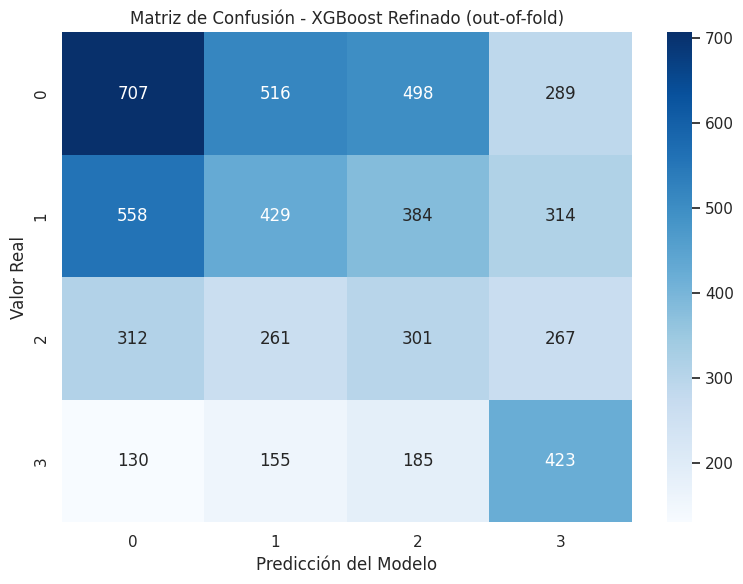

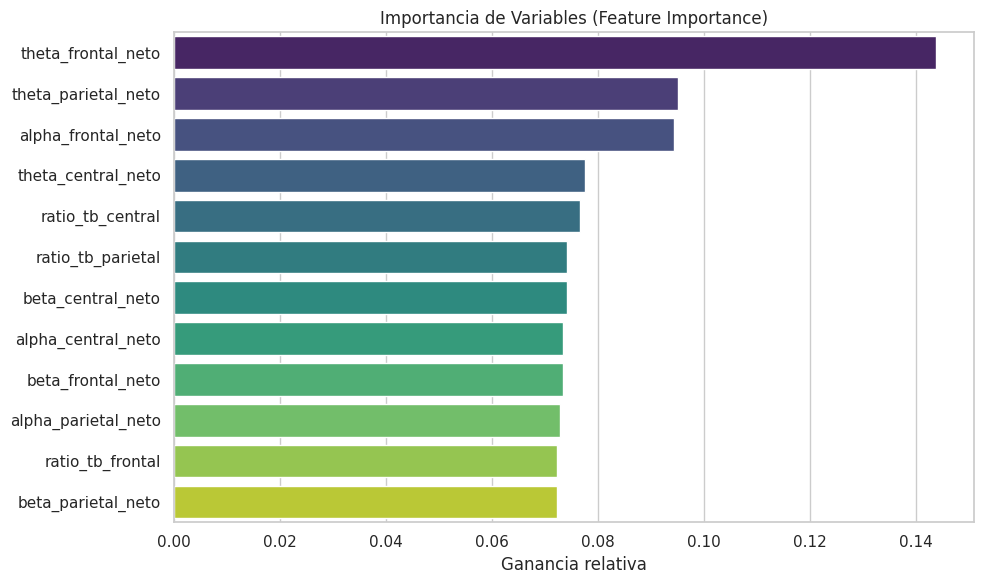

🏃 View run GridSearch_SMOTETomek_Ratios at: https://dagshub.com/GaboGolCs/PainPredict-Neuro.mlflow/#/experiments/2/runs/62659b89a98b4ebfa472862e474660c4
🧪 View experiment at: https://dagshub.com/GaboGolCs/PainPredict-Neuro.mlflow/#/experiments/2

¡Proceso finalizado! Métricas y artefactos registrados, y modelo guardado en MLflow.


In [ ]:
import os

RUTA_DRIVE = '/content/drive/Shareddrives/DATA_GPI/Grupo3_Desarrollo/Hito 4 - Actividad 1/Imagenes'

with mlflow.start_run(run_name="GridSearch_SMOTETomek_Ratios"):

    # 1) Búsqueda de hiperparámetros con aislamiento de pacientes.
    print("Iniciando búsqueda de hiperparámetros con validación cruzada por grupos...")
    grid_search.fit(X, y, groups=grupos)

    mejor_modelo  = grid_search.best_estimator_      # Pipeline reentrenado con la mejor config.
    mejores_params = grid_search.best_params_
    print("\nMejores hiperparámetros encontrados:")
    for k, v in mejores_params.items():
        print(f"  {k}: {v}")

    # 2) Evaluación honesta: predicciones out-of-fold sobre datos reales (sin balanceo en test).
    #    Se clona la configuración ganadora y se predice cada muestra fuera de su fold.
    print("\nGenerando predicciones out-of-fold para una evaluación no sesgada...")
    preds = cross_val_predict(
        mejor_modelo, X, y,
        groups=grupos,
        cv=gkf,
        n_jobs=-1
    )

    # 3) Métricas agregadas (promedio macro: trata a las 4 clases con igual peso).
    acc      = accuracy_score(y, preds)
    macro_f1 = f1_score(y, preds, average='macro')
    prec     = precision_score(y, preds, average='macro', zero_division=0)
    rec      = recall_score(y, preds, average='macro', zero_division=0)

    # Registro en MLflow/DagsHub.
    mlflow.log_params(mejores_params)
    mlflow.log_metrics({
        "Accuracy":  acc,
        "Macro_F1":  macro_f1,
        "Precision": prec,
        "Recall":    rec
    })

    # Persistencia del mejor modelo (Pipeline completo) como artefacto versionado.
    mlflow.sklearn.log_model(mejor_modelo, "modelo_xgb_eeg_refinado")

    # Comparación explícita contra el modelo base.
    F1_BASELINE = 0.3257
    delta = macro_f1 - F1_BASELINE

    print("\n--- MÉTRICAS DEL MEJOR MODELO (evaluación out-of-fold) ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {macro_f1:.4f}   (baseline: {F1_BASELINE:.4f} | Δ = {delta:+.4f})")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")

    print("\n--- REPORTE DETALLADO POR CLASE ---")
    print(classification_report(y, preds, digits=4,
                                target_names=['Clase 0', 'Clase 1', 'Clase 2', 'Clase 3']))

    # 4) Matriz de confusión: revela hacia qué clase se concentran los errores del modelo.
    cm = confusion_matrix(y, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[0, 1, 2, 3], yticklabels=[0, 1, 2, 3])
    plt.title('Matriz de Confusión - XGBoost Refinado (out-of-fold)')
    plt.ylabel('Valor Real')
    plt.xlabel('Predicción del Modelo')
    plt.tight_layout()
    # Save to a temporary file, then log that file to MLflow.
    confusion_matrix_path = os.path.join(RUTA_DRIVE, "matriz_confusion.png")
    plt.savefig(confusion_matrix_path, dpi=150)   # se guarda en drive
    mlflow.log_artifact(confusion_matrix_path)
    plt.show()

    # 5) Importancia de variables: cuánto aporta cada feature a las decisiones del árbol.
    #    Se lee del clasificador final, ya ajustado sobre el conjunto completo balanceado.
    xgb_final    = mejor_modelo.named_steps['xgb']
    importancias = xgb_final.feature_importances_

    orden = np.argsort(importancias)[::-1]   # de mayor a menor importancia
    feats_ordenadas = [FEATURES[i] for i in orden]
    imp_ordenadas   = importancias[orden]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=imp_ordenadas, y=feats_ordenadas, palette='viridis')
    plt.title('Importancia de Variables (Feature Importance)')
    plt.xlabel('Ganancia relativa')
    plt.tight_layout()
    feature_importance_path = os.path.join(RUTA_DRIVE, "feature_importance.png")
    plt.savefig(feature_importance_path, dpi=150)   # se guarda en drive
    mlflow.log_artifact(feature_importance_path)
    plt.show()

print("\n¡Proceso finalizado! Métricas y artefactos registrados, y modelo guardado en MLflow.")

## Resumen para el reporte analítico

Esta celda imprime de forma ordenada los datos que alimentan el reporte Word: la variación del
Macro F1 frente al baseline, la lectura de la matriz de confusión (clase con más confusiones) y
el ranking de importancia que permite comparar los ratios Theta/Beta contra las ondas aisladas.

In [ ]:
print("="*60)
print("RESUMEN PARA EL REPORTE ANALÍTICO")
print("="*60)

print(f"\n1) MACRO F1")
print(f"   Baseline previo : {F1_BASELINE:.4f}")
print(f"   Modelo refinado : {macro_f1:.4f}")
print(f"   Variación       : {delta:+.4f}  ({(delta/F1_BASELINE*100):+.1f}%)")

print(f"\n2) MATRIZ DE CONFUSIÓN — análisis del sesgo")
for clase in range(4):
    total_real    = cm[clase].sum()
    aciertos      = cm[clase, clase]
    # Clase hacia la que más se confunde esta clase real (excluyendo el acierto).
    fila = cm[clase].copy(); fila[clase] = -1
    clase_confundida = int(np.argmax(fila))
    print(f"   Clase {clase}: aciertos {aciertos}/{total_real} "
          f"({aciertos/total_real*100:4.1f}%) | más confundida con Clase {clase_confundida}")

print(f"\n3) IMPORTANCIA DE VARIABLES (ranking)")
for i, (f, imp) in enumerate(zip(feats_ordenadas, imp_ordenadas), 1):
    marca = "  <-- ratio T/B" if f.startswith("ratio_tb") else ""
    print(f"   {i:2d}. {f:24s} {imp:.4f}{marca}")

# Aporte agregado de los ratios frente al resto de features.
mask_ratio = np.array([f.startswith("ratio_tb") for f in feats_ordenadas])
imp_ratios = imp_ordenadas[mask_ratio].sum()
imp_ondas  = imp_ordenadas[~mask_ratio].sum()
print(f"\n   Importancia agregada ratios Theta/Beta : {imp_ratios:.4f}")
print(f"   Importancia agregada ondas aisladas    : {imp_ondas:.4f}")

RESUMEN PARA EL REPORTE ANALÍTICO

1) MACRO F1
   Baseline previo : 0.3257
   Modelo refinado : 0.3223
   Variación       : -0.0034  (-1.1%)

2) MATRIZ DE CONFUSIÓN — análisis del sesgo
   Clase 0: aciertos 707/2010 (35.2%) | más confundida con Clase 1
   Clase 1: aciertos 429/1685 (25.5%) | más confundida con Clase 0
   Clase 2: aciertos 301/1141 (26.4%) | más confundida con Clase 0
   Clase 3: aciertos 423/893 (47.4%) | más confundida con Clase 2

3) IMPORTANCIA DE VARIABLES (ranking)
    1. theta_frontal_neto       0.1438
    2. theta_parietal_neto      0.0951
    3. alpha_frontal_neto       0.0943
    4. theta_central_neto       0.0775
    5. ratio_tb_central         0.0766  <-- ratio T/B
    6. ratio_tb_parietal        0.0742  <-- ratio T/B
    7. beta_central_neto        0.0742
    8. alpha_central_neto       0.0735
    9. beta_frontal_neto        0.0735
   10. alpha_parietal_neto      0.0729
   11. ratio_tb_frontal         0.0722  <-- ratio T/B
   12. beta_parietal_neto       0.